In [1]:
import typing as T
import pickle
import json
import os
import pathlib
import pathlib as P
import sys
import pandas as pd
import itertools as it
import functools as ft
import operator as opr
import collections as clt
import math
from math import pi
import re

In [2]:
prj_root = P.Path("__file__").absolute().parent.parent.parent
if (p := str(prj_root)) not in sys.path:
  sys.path.append(p)

In [3]:
import util.metrics as um
import sklearn.metrics as metrics

In [4]:
import numpy as np
import scipy as sci
import scipy.stats as stats
import scipy.sparse as sp
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as colors
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm

In [5]:
ns = ['cc', 'mf', 'bp']
ontology_lst = ["cellular_component",
                "molecular_function",
                "biological_process"]

In [6]:
data_path = [f"/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/{x}_data.pkl"
             for x in ["train", "valid", "test"]]
prot_data = pd.concat([pd.read_pickle(x) for x in data_path], ignore_index=True)

In [7]:
prot_test_data = pd.read_pickle(data_path[-1])

In [8]:
prot_test_lst = prot_test_data["proteins"].to_list()

In [9]:
prot_test_set = set(prot_test_lst)

In [10]:
prot_labels = []
for n in ns:
    y_label = prj_root / "data" / n / "label.pkl"
    with open(y_label, "rb") as f:
        labels = pickle.load(f)
    tmp = clt.defaultdict(list)
    for k, v in zip(labels["protein"], labels["go"]):
        tmp[k].append(v)
    prot_labels.append(tmp)

In [11]:
label_dir = P.Path("/data0/zhaojianxiang/data/")
curr_labels = []
for n in ns:
    label_path = label_dir / n / "go_list.txt"
    with open(label_path, "r") as f:
        labels = f.read().splitlines()
    curr_labels.append(labels)
namespace_terms = dict(zip(ontology_lst, curr_labels))

In [12]:
nspace_ti = {k: {x: i for i, x in enumerate(v)}
             for k, v in namespace_terms.items()}

In [13]:
ti_lst = list(nspace_ti.values())

In [14]:
# get protein name id
name_path = prj_root / "data" / "protein_name.txt"
with open(name_path, "r") as f:
    prot_lst = f.read().splitlines()# load prot names

In [15]:
# convert protein idx and label idx to protein name and go term respectively
for i, n in enumerate(ontology_lst):
    prot_labels[i] = {
        prot_lst[k]: [namespace_terms[n][x] for x in v]
        for k, v in prot_labels[i].items()
    }


In [16]:
ci_path = "/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/term_counts_with_position-111.pkl"
term_count_ic = pd.read_pickle(ci_path)

In [17]:
label_dir = P.Path("/data0/zhaojianxiang/data/")
curr_labels = []
for n in ns:
    label_path = label_dir / n / "go_list.txt"
    with open(label_path, "r") as f:
        labels = f.read().splitlines()
    curr_labels.append(labels)

namespace_terms = dict(zip(ontology_lst, curr_labels))

In [18]:
# load structure plddt data
plddt_path = prj_root / "data" / "protein_plddt_avgRes.csv"
plddt_df = pd.read_csv(plddt_path)

In [19]:
plddt_df = plddt_df.rename(columns={"Protein": "proteins",
                            "Avg_pLDDT": "pLDDT"})

In [20]:
plddt_df

,proteins,pLDDT
0,Q5BHH6,94.27
1,Q5BGS1,88.58
2,Q5BHC4,74.61
3,C8VRD6,83.38
4,Q5BG78,94.68
...,...,...
124068,Q96DC8,90.40
124069,Q9VAM6,91.85
124070,Q9VNF9,87.92
124071,Q9VT33,83.72


In [21]:
plddt_df["pLDDT"].quantile(np.linspace(0, 1, 20, endpoint=False))

0.00    25.720
0.05    53.350
0.10    58.750
0.15    62.460
0.20    65.730
0.25    68.710
0.30    71.520
0.35    74.070
0.40    76.330
0.45    78.340
0.50    80.230
0.55    81.980
0.60    83.720
0.65    85.390
0.70    87.020
0.75    88.690
0.80    90.310
0.85    91.947
0.90    93.680
0.95    95.620
Name: pLDDT, dtype: float64

In [22]:
prot_plddt = dict(zip(plddt_df["proteins"], plddt_df["pLDDT"]))

In [23]:
method_names = [
  "ProGO-PFL",
  "DeepGOPlus",
  "TALE",
  "DeepFRI",
  "DeepGraphGO",
  "PFresGO",
]
method_predictions = clt.defaultdict(list)


In [24]:
# load method

for ont in ns:
  # N = 5
  # tmp_lst = []
  # for i in range(N):
  #   pred_path = f"/data0/shaojiangyi/pprogo-flg-1/results/HGAT_{ont}_{i}.npz"
  #   tmp = np.load(pred_path)
  #   pred = np.stack((tmp["labels"], tmp["preds"]), axis=0)
  #   tmp_lst.append(pred)
  pred_path = f"/data0/shaojiangyi/pprogo-flg-1/results/HGAT_{ont}_best.npz"
  tmp = np.load(pred_path)
  pred = np.stack((tmp["labels"], tmp["preds"]), axis=0)
  # tmp_lst.append(pred)
  # # average the predictions
  # pred = np.stack((tmp_lst[0][0], np.mean([x[1] for x in tmp_lst], axis=0)), axis=0)
  # pred_path = f"/data0/shaojiangyi/pprogo-flg-1/results/HGAT_{ont}_2.npz"
  # tmp = np.load(pred_path)
  # pred = np.stack((tmp["labels"], tmp["preds"]), axis=0)
  method_predictions["ProGO-PFL"].append(pred)

In [25]:
root_paths = [
    "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-deepgoplus/data-netgo",
    "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-tale/data-netgo",
    "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-deepfri/data-netgo",
    "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-gcn",
    "/data0/shaojiangyi/pprogo-flg-1/netgo_benchmark/netgo-pfresgo/data-netgo",
]

In [26]:
for label_dir, method_name in zip(root_paths,
                                  method_names[1:]):
  pred_paths = [P.Path(label_dir) / f"{ns[i]}_result_aligned.npy" for i in range(len(ns))]
  for i, pred_path in enumerate(pred_paths):
    if not pred_path.exists():
      print(f"File {pred_path} does not exist.")
      continue
    preds = np.load(pred_path)
    if preds.ndim == 1:
      preds = preds[:, None]
    # pring shape
    print(f"Method: {method_name}, Namespace: {ns[i]}, Shape: {preds.shape}")
    method_predictions[method_name].append(preds)

Method: DeepGOPlus, Namespace: cc, Shape: (2, 268, 2852)
Method: DeepGOPlus, Namespace: mf, Shape: (2, 505, 6786)
Method: DeepGOPlus, Namespace: bp, Shape: (2, 491, 21677)
Method: TALE, Namespace: cc, Shape: (2, 268, 2852)
Method: TALE, Namespace: mf, Shape: (2, 505, 6786)
Method: TALE, Namespace: bp, Shape: (2, 491, 21677)
Method: DeepFRI, Namespace: cc, Shape: (2, 268, 2852)
Method: DeepFRI, Namespace: mf, Shape: (2, 505, 6786)
Method: DeepFRI, Namespace: bp, Shape: (2, 491, 21677)
Method: DeepGraphGO, Namespace: cc, Shape: (2, 268, 2852)
Method: DeepGraphGO, Namespace: mf, Shape: (2, 505, 6786)
Method: DeepGraphGO, Namespace: bp, Shape: (2, 491, 21677)
Method: PFresGO, Namespace: cc, Shape: (2, 268, 2852)
Method: PFresGO, Namespace: mf, Shape: (2, 505, 6786)
Method: PFresGO, Namespace: bp, Shape: (2, 491, 21677)


In [27]:
um.roc_auc_score(*method_predictions["ProGO-PFL"][0])

np.float64(0.8681195669291341)

In [28]:
for i, x in enumerate(ns):
    for m, pred in method_predictions.items():
        print(f"{x}, {m}, {um.roc_auc_score(*pred[i])}")

cc, ProGO-PFL, 0.8681195669291341
cc, DeepGOPlus, 0.6596406163220523
cc, TALE, 0.7276873310486855
cc, DeepFRI, 0.598338884804147
cc, DeepGraphGO, 0.6708383711338162
cc, PFresGO, 0.6493906752463395
mf, ProGO-PFL, 0.9418654282752104
mf, DeepGOPlus, 0.7169896002738108
mf, TALE, 0.7399764751338559
mf, DeepFRI, 0.6255760190801761
mf, DeepGraphGO, 0.6615624853231405
mf, PFresGO, 0.710654834887166
bp, ProGO-PFL, 0.7483030099291542
bp, DeepGOPlus, 0.5878938325081672
bp, TALE, 0.5383525891782571
bp, DeepFRI, 0.5424155817304281
bp, DeepGraphGO, 0.6484832141995457
bp, PFresGO, 0.6001698737353945


In [29]:
prot_test_labels = [{x: y for x, y in d.items() if x in prot_test_set}
                    for d in prot_labels]

In [30]:
prot_test_index = {x: i for i, x in enumerate(prot_test_lst)}

In [31]:

def combine_predictions(pred_lst: T.List[np.ndarray], 
                        test_labels: T.List[T.Dict[str, T.List[str]]], 
                        test_index: T.List[str]):
    n_classes = sum(p.shape[-1] for p in pred_lst)
    new_pred = np.zeros((2, len(test_index), n_classes), dtype=np.float32)
    
    # Create a mapping from sample name to index in the final prediction
    sample_to_final_idx = {sample: idx for idx, sample in enumerate(test_index)}
    
    col_bias = 0
    for i, p in enumerate(pred_lst):
        np_samples = p.shape[-2]
        nc_classes = p.shape[-1]
        
        # Get the sample names for this prediction (assuming they're in order of the keys)
        sample_names = list(test_labels[i].keys())
        
        # Create mapping from current prediction rows to final prediction rows
        src_to_tgt_row_mapping = []
        for j, sample_name in enumerate(sample_names):
            if sample_name in sample_to_final_idx:
                final_row_idx = sample_to_final_idx[sample_name]
                src_to_tgt_row_mapping.append((j, final_row_idx))
        
        # Copy the data using the mappings
        for src_row, tgt_row in src_to_tgt_row_mapping:
            # Copy both target (index 0) and prediction (index 1)
            new_pred[0, tgt_row, col_bias:col_bias + nc_classes] = p[0, src_row, :]
            new_pred[1, tgt_row, col_bias:col_bias + nc_classes] = p[1, src_row, :]
        
        col_bias += nc_classes
    
    return new_pred

In [32]:
comb_fn = ft.partial(combine_predictions, test_labels=prot_test_labels, test_index=prot_test_index)

In [33]:
# combine the cc mf bp result
method_combined = {m: comb_fn(p) for m, p in method_predictions.items()}

In [34]:
for m, pred in method_combined.items():
        print(f"ALL, {m}, {um.roc_auc_score(*pred)}")

ALL, ProGO-PFL, 0.8869029615560773
ALL, DeepGOPlus, 0.6464257909725001
ALL, TALE, 0.6063387565368635
ALL, DeepFRI, 0.6549850048980769
ALL, DeepGraphGO, 0.814159264923056
ALL, PFresGO, 0.6870522934794524


In [35]:
# load structure similarity
fsk_path = prj_root / "data" / "predicted_structure" / "foldseek_similarity_matrix.npz"
fsk_mat = sp.load_npz(fsk_path)

In [36]:
# load index to name
fskid_path = prj_root / "data" / "predicted_structure" / "foldseek_id_to_index.json"
with open(fskid_path, "r") as h:
    fskid_dict = json.load(h)

In [37]:
fsk_mat

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 78271307 stored elements and shape (117783, 117783)>

In [38]:
def calculate_row_means_efficient(sparse_matrix):
    """
    Calculate mean of non-zero elements in each row using matrix operations
    """
    # Convert to CSR format for efficient row operations
    csr_matrix = sparse_matrix.tocsr()
    
    # Vector of ones for dot product
    ones = np.ones(csr_matrix.shape[1])
    
    # Sum of elements in each row
    row_sums = csr_matrix.dot(ones)
    
    # Count non-zero elements per row
    row_nnz = np.array(csr_matrix.getnnz(axis=1))  # More efficient way
    
    # Calculate means
    row_means = np.divide(row_sums, row_nnz, 
                         out=np.zeros_like(row_sums, dtype=float), 
                         where=row_nnz!=0)
    
    return row_means

In [39]:
sim_ary = calculate_row_means_efficient(fsk_mat)

In [40]:
sim_ary

array([0.14146203, 0.42653072, 0.20625882, ..., 0.36899538, 0.74899171,
       0.36577181])

In [41]:
sim_ary.shape

(117783,)

In [42]:
np.quantile(sim_ary, np.linspace(0,1,20,endpoint=False))

array([0.05750963, 0.18685914, 0.22583625, 0.2548793 , 0.27869044,
       0.29937918, 0.31846347, 0.33495422, 0.35156145, 0.36773452,
       0.38421886, 0.4009176 , 0.41820799, 0.43772376, 0.46012405,
       0.48614716, 0.51655875, 0.55523183, 0.61196357, 0.68767938])

In [43]:
# select the test data
test_row = [i for x in prot_test_lst 
            if (i := fskid_dict.get(x)) is not None]

In [44]:
test_src_row = [i for i, x in enumerate(prot_test_lst)
                if fskid_dict.get(x) is not None]

In [45]:
len(test_row)

825

In [46]:
len(prot_test_lst)

871

In [47]:
sim_test_ary = np.zeros(len(prot_test_lst), dtype=np.float32)
sim_test_ary[test_src_row] = sim_ary[test_row]

In [48]:
np.quantile(sim_test_ary, np.linspace(0,1,10,endpoint=False))

array([0.        , 0.18740487, 0.25035888, 0.29239249, 0.33914918,
       0.37060958, 0.40467915, 0.4461062 , 0.50350767, 0.56367368])

In [49]:
prot_test_fsk = dict(zip(prot_test_lst, sim_test_ary))

In [50]:
prottest_fskdf = pd.DataFrame({"proteins": prot_test_lst,
                               "sim": sim_test_ary})

In [51]:
prot_sim_ths = [None] + np.quantile(sim_ary, 
                                    np.linspace(0.1,1,10,endpoint=False)).round(2).tolist() + [None]

In [52]:
protsim_range = [(prot_sim_ths[i], prot_sim_ths[i+1])
                 for i in range(len(prot_sim_ths)-1)]

In [53]:
protsim_range

[(None, 0.23),
 (0.23, 0.27),
 (0.27, 0.31),
 (0.31, 0.34),
 (0.34, 0.37),
 (0.37, 0.4),
 (0.4, 0.43),
 (0.43, 0.48),
 (0.48, 0.53),
 (0.53, 0.63),
 (0.63, None)]

In [54]:
def get_range_labelname(low, high):
    if low is None:
        return f"(-inf, {high})"
    elif high is None:
        return f"[{low}, +inf)"
    else:
        return f"[{low}, {high})" 

In [55]:
def rocauc_range(
               targs: np.ndarray, 
               preds: np.ndarray,
               prot_dict: T.Dict[str, int],
               protein_sim: pd.DataFrame,
               prot_sim_range: T.Tuple = None, # select proteins
               ):
  if prot_sim_range is None:
    return um.roc_auc_score(targs, preds)
  
  min_psim, max_psim = np.trunc(protein_sim["sim"].min()), protein_sim["sim"].max()

  r1, r2 = prot_sim_range

  if r1 is None: r1 = min_psim
  if r2 is None: r2 = max_psim

  r_indeices = protein_sim[(protein_sim["sim"] >= r1) &
                          (protein_sim["sim"] < r2)]["proteins"]\
                            .transform(lambda x: prot_dict.get(x, pd.NA))\
                            .dropna().to_numpy(dtype=int)
  
  if len(r_indeices) <= 0:
    return None, None
  else:
    sub_targs = targs[r_indeices]
    sub_preds = preds[r_indeices]
    if sub_targs.sum() <= 0: 
      return None, None
    else:
      return um.roc_auc_score(sub_targs, sub_preds), r_indeices

In [56]:
roc_fn = [ft.partial(rocauc_range, prot_dict=prot_test_index,
                     protein_sim=prottest_fskdf,
                     prot_sim_range=r,
                     )
           for r in protsim_range]

In [57]:
perf_data = clt.defaultdict(list)
for m, pred in method_combined.items():
    for k, func in tqdm(enumerate(roc_fn),ncols=120):
        perf_data["method"].append(m)
        roc_value, inds = func(targs=pred[0], preds=pred[1])
        perf_data["roc"].append(roc_value)
        perf_data["sim"].append(get_range_labelname(*protsim_range[k]))
        tmp_lst = [prot_test_lst[i] for i in inds]
        perf_data["proteins"].append(tmp_lst)
        perf_data["n_proteins"].append(len(tmp_lst))

11it [00:02,  4.10it/s]
11it [00:02,  4.19it/s]
11it [00:02,  4.15it/s]
11it [00:02,  4.05it/s]
11it [00:02,  4.06it/s]
11it [00:02,  4.16it/s]


In [58]:
perf_df = pd.DataFrame(perf_data)

In [59]:
perf_df

,method,roc,sim,proteins,n_proteins
0,ProGO-PFL,0.841811,"(-inf, 0.23)","[Q55AH8, Q9VDY6, Q8MQV7, A2AGT5, Q68FD9, Q7TSV...",135
1,ProGO-PFL,0.917217,"[0.23, 0.27)","[Q55CR5, Q8T867, Q54SP2, Q54BQ2, Q9VA75, Q9VLV...",78
2,ProGO-PFL,0.920961,"[0.27, 0.31)","[Q55BE1, Q80VM3, Q03771, P49029, Q3MIT2, Q8BXT...",80
3,ProGO-PFL,0.934809,"[0.31, 0.34)","[Q54NT2, Q9VZU4, P91929, Q9CXV9, Q501P1, Q8K1N...",58
4,ProGO-PFL,0.913857,"[0.34, 0.37)","[Q54MM9, Q9VV87, Q8BZT9, Q99JF5, Q9JMH7, Q8R13...",81
...,...,...,...,...,...
61,PFresGO,0.773947,"[0.4, 0.43)","[Q55GJ9, Q54RX6, Q54PP1, Q9VKY3, Q960M5, Q3U2U...",73
62,PFresGO,0.807535,"[0.43, 0.48)","[Q554U0, P21837, Q54KD9, Q54IT0, Q54I12, Q9CQ4...",81
63,PFresGO,0.702765,"[0.48, 0.53)","[Q8T2G9, Q9VF27, Q91WG7, Q8BPX9, Q91W98, Q8BGC...",84
64,PFresGO,0.780314,"[0.53, 0.63)","[Q54DE4, Q8MSW4, Q8BK84, Q8VCL5, Q3UHK1, O9470...",75


In [60]:
perf_df[perf_df["method"] == "ProGO-PFL"]

,method,roc,sim,proteins,n_proteins
0,ProGO-PFL,0.841811,"(-inf, 0.23)","[Q55AH8, Q9VDY6, Q8MQV7, A2AGT5, Q68FD9, Q7TSV...",135
1,ProGO-PFL,0.917217,"[0.23, 0.27)","[Q55CR5, Q8T867, Q54SP2, Q54BQ2, Q9VA75, Q9VLV...",78
2,ProGO-PFL,0.920961,"[0.27, 0.31)","[Q55BE1, Q80VM3, Q03771, P49029, Q3MIT2, Q8BXT...",80
3,ProGO-PFL,0.934809,"[0.31, 0.34)","[Q54NT2, Q9VZU4, P91929, Q9CXV9, Q501P1, Q8K1N...",58
4,ProGO-PFL,0.913857,"[0.34, 0.37)","[Q54MM9, Q9VV87, Q8BZT9, Q99JF5, Q9JMH7, Q8R13...",81
5,ProGO-PFL,0.867813,"[0.37, 0.4)","[Q54XF7, Q9VDS7, A0A0B4LID7, Q8MQZ4, Q9D8C3, Q...",77
6,ProGO-PFL,0.909127,"[0.4, 0.43)","[Q55GJ9, Q54RX6, Q54PP1, Q9VKY3, Q960M5, Q3U2U...",73
7,ProGO-PFL,0.929148,"[0.43, 0.48)","[Q554U0, P21837, Q54KD9, Q54IT0, Q54I12, Q9CQ4...",81
8,ProGO-PFL,0.817352,"[0.48, 0.53)","[Q8T2G9, Q9VF27, Q91WG7, Q8BPX9, Q91W98, Q8BGC...",84
9,ProGO-PFL,0.900006,"[0.53, 0.63)","[Q54DE4, Q8MSW4, Q8BK84, Q8VCL5, Q3UHK1, O9470...",75


In [61]:
perf_df["plddt"] = perf_df["proteins"].apply(lambda xs: [prot_plddt.get(x, 0.) for x in xs])

In [62]:
perf_df

,method,roc,sim,proteins,n_proteins,plddt
0,ProGO-PFL,0.841811,"(-inf, 0.23)","[Q55AH8, Q9VDY6, Q8MQV7, A2AGT5, Q68FD9, Q7TSV...",135,"[75.84, 72.3, 71.1, 76.16, 45.29, 77.2, 90.55,..."
1,ProGO-PFL,0.917217,"[0.23, 0.27)","[Q55CR5, Q8T867, Q54SP2, Q54BQ2, Q9VA75, Q9VLV...",78,"[52.84, 62.64, 74.64, 85.0, 67.37, 55.11, 61.0..."
2,ProGO-PFL,0.920961,"[0.27, 0.31)","[Q55BE1, Q80VM3, Q03771, P49029, Q3MIT2, Q8BXT...",80,"[69.22, 84.25, 91.71, 92.07, 88.62, 80.58, 82...."
3,ProGO-PFL,0.934809,"[0.31, 0.34)","[Q54NT2, Q9VZU4, P91929, Q9CXV9, Q501P1, Q8K1N...",58,"[83.2, 83.15, 86.47, 87.85, 84.02, 66.71, 77.0..."
4,ProGO-PFL,0.913857,"[0.34, 0.37)","[Q54MM9, Q9VV87, Q8BZT9, Q99JF5, Q9JMH7, Q8R13...",81,"[91.13, 83.1, 90.16, 92.53, 88.3, 74.91, 62.95..."
...,...,...,...,...,...,...
61,PFresGO,0.773947,"[0.4, 0.43)","[Q55GJ9, Q54RX6, Q54PP1, Q9VKY3, Q960M5, Q3U2U...",73,"[92.38, 91.03, 92.84, 84.57, 71.98, 85.63, 89...."
62,PFresGO,0.807535,"[0.43, 0.48)","[Q554U0, P21837, Q54KD9, Q54IT0, Q54I12, Q9CQ4...",81,"[76.09, 90.71, 83.9, 77.07, 81.44, 90.7, 73.42..."
63,PFresGO,0.702765,"[0.48, 0.53)","[Q8T2G9, Q9VF27, Q91WG7, Q8BPX9, Q91W98, Q8BGC...",84,"[81.51, 85.51, 78.98, 82.28, 83.96, 80.25, 88...."
64,PFresGO,0.780314,"[0.53, 0.63)","[Q54DE4, Q8MSW4, Q8BK84, Q8VCL5, Q3UHK1, O9470...",75,"[77.19, 91.78, 86.91, 89.19, 82.27, 95.72, 79...."


In [63]:
def parse_similarity_interval(sim_str):
    """Parse similarity interval string and return midpoint for sorting"""
    # Handle special cases
    if sim_str.find("(-inf") != -1:
        # Extract the upper bound
        upper = float(re.findall(r',\s*([\d.]+)\)', sim_str)[0])
        return upper - 0.1  # Assign a value slightly below the upper bound
    elif sim_str.find("+inf)") != -1:
        # Extract the lower bound
        lower = float(re.findall(r'\[([\d.]+),', sim_str)[0])
        return lower + 0.1  # Assign a value slightly above the lower bound
    else:
        # Regular interval [a, b)
        bounds = re.findall(r'([\d.]+)', sim_str)
        return (float(bounds[0]) + float(bounds[1])) / 2

In [ ]:
# clst = [
# "#F79D8E",
# "#8180AA",
# "#92B6DD",
# "#A2D8E7",
# "#BDE3DA",
# "#F7E6F0",
# "#F4CEE1",
# "#D7D6E6",
# "#DDD1C4",
# "#F7ECE5",
# "#E4E5E5",
# ]

In [64]:
clst = ['#F0BB40', '#D9596B', '#AA2493', '#6400A6', '#4B1476', '#0F097F']

In [69]:
def plot_similarity_analysis_combined(df, figsize=(12, 10),
                                      method_colors = None):
    """
    Advanced version: Combined visualization with better layout
    """
    # Prepare data
    plt.rcParams.update({
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'font.family': 'sans-serif',
        'font.sans-serif': 'Arial',
        'font.size': 16
    })
    df_sorted = df.copy()
    df_sorted['sim_order'] = df_sorted['sim'].apply(parse_similarity_interval)
    df_sorted = df_sorted.sort_values('sim_order')
    
    # Expand pLDDT data
    plddt_data = []
    for _, row in df_sorted.iterrows():
        for plddt_val in row['plddt']:
            plddt_data.append({
                'sim': row['sim'],
                'plddt': plddt_val,
                'method': row['method'],
                'sim_order': row['sim_order']
            })
    plddt_df = pd.DataFrame(plddt_data)
    
    # Create subplots
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 2], hspace=0.1)
    
    # Top: ROC comparison
    ax1 = fig.add_subplot(gs[0])
    methods = df_sorted['method'].unique()
    bias = 4
    n_method = len(methods)
    if method_colors is not None:
        assert len(method_colors) >= n_method, "Not enough colors provided for methods"
        colors = method_colors
    else:
        colors = plt.cm.magma(np.linspace(0, 1, n_method+bias)[:n_method][::-1])
    
    sim_labels = df_sorted['sim'].unique()
    for method, color in zip(methods, colors):
        method_data = df_sorted[df_sorted['method'] == method]
        x_pos = range(len(method_data))
        
        if method == 'ProGO-PFL':
            ax1.plot(x_pos, method_data['roc'], 'o-', 
                    label=method, color=color, linewidth=3, markersize=8)
        else:
            ax1.plot(x_pos, method_data['roc'], 'o-', 
                    label=method, color=color, linewidth=2, markersize=6, alpha=0.8)
    
    ax1.set_ylabel('ROC', fontdict={"size": 36})
    # ax1.set_title('Method Comparison Across Similarity Bins')
    ax1.set_xticks(range(len(sim_labels)))
    ax1.set_xticklabels([])  # Remove x labels for top plot
    ax1.legend(bbox_to_anchor=(0.3, 1), loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Middle: Sample counts
    ax2 = fig.add_subplot(gs[1])
    sample_counts = df_sorted.groupby('sim')['n_proteins'].first()
    bars = ax2.bar(range(len(sample_counts)), sample_counts.values, 
                #    color="#8180AA", 
                   color = "#F7B52C",
                   alpha=0.7,
                   )
    ax2.set_ylabel('Count', fontdict={"size": 36})
    # ax2.set_title('Sample Counts')
    ax2.set_xticks(range(len(sim_labels)))
    ax2.set_xticklabels([])
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    # Bottom: pLDDT distribution
    ax3 = fig.add_subplot(gs[2])
    plddt_by_sim = [plddt_df[plddt_df['sim'] == sim]['plddt'].values for sim in sim_labels]
    
    bp = ax3.boxplot(plddt_by_sim, tick_labels=sim_labels, patch_artist=True)
    for patch in bp['boxes']:
        # patch.set_facecolor("#F4CEE1")
        patch.set_facecolor("#AA67BA")
        patch.set_alpha(0.7)
    
    # set median color
    for median in bp['medians']:
        median.set(color='#F9B826', linewidth=2)
    
    ax3.set_xlabel('Structure Similarity', fontdict={"size": 36})
    ax3.set_ylabel('pLDDT', fontdict={"size": 36})
    # ax3.set_title('pLDDT Distribution')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)
    
    return fig


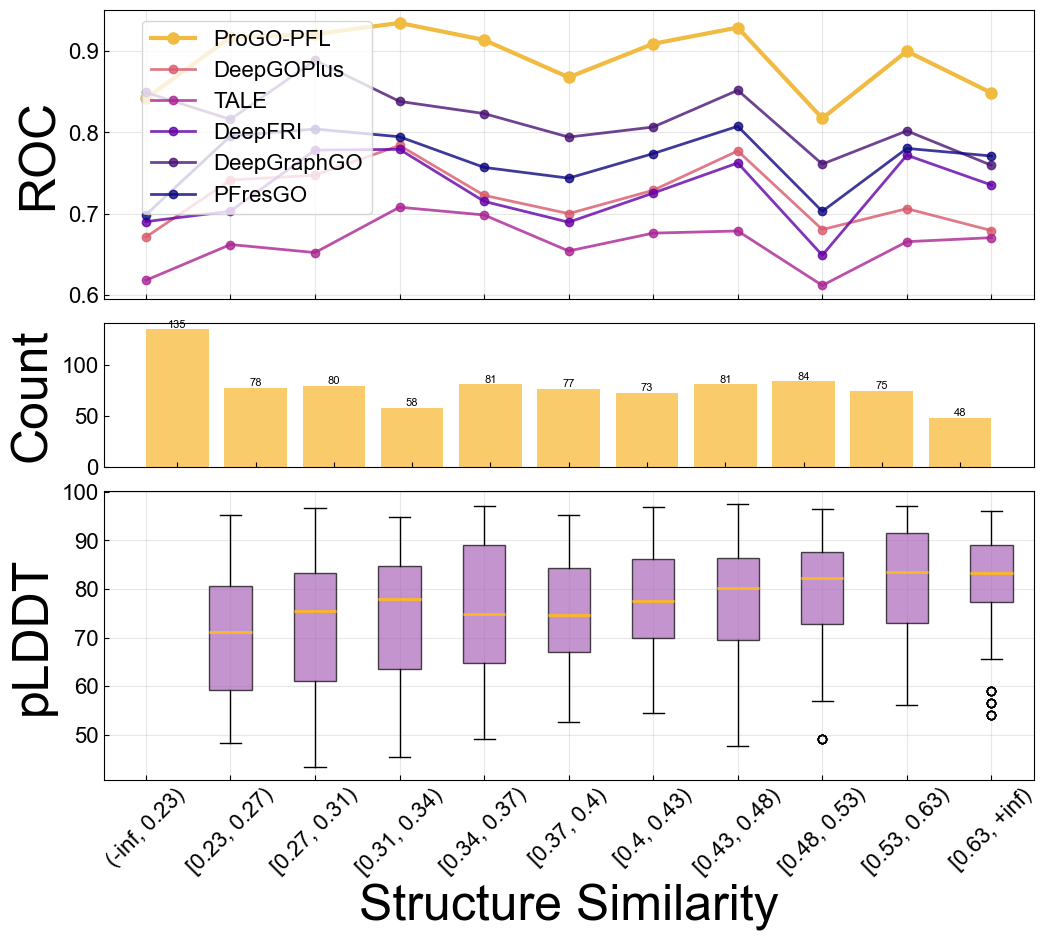

In [70]:
figure = plot_similarity_analysis_combined(perf_df, method_colors=clst)

In [71]:
save_dir = prj_root / "notebooks" / "inductive_learning" / "figures"
save_path = save_dir / f"plddt_perf_1.png"
figure.savefig(save_path, dpi=300,bbox_inches="tight")
save_path = save_dir / "plddt_perf_2.svg"
figure.savefig(save_path, bbox_inches="tight")